<h1 style="color:green;font-size:22px;">Function 2 - Black-Box Optimisation</h1>
<h1 style="color:#0000CD;font-size:19px;">Objective and reading guide</h1>

Function 2 is a two-dimensional black-box objective over the bounded domain $[0,1]^2$. Its analytical form and interpretation are unknown. The goal is to **find the input configuration that maximises the observed value of Function 2** under a limited sequential-evaluation budget.

An intuitive analogy is tuning two controls on an unknown system that returns a single score. Because the response surface cannot be observed directly, each new query must be chosen using only the results collected so far. Bayesian optimisation supports this process by balancing exploration of uncertain regions with refinement of promising ones.

The 13 historical queries are organised by strategy phase:

1. **Global exploration** (Weeks 1–4)
2. **High-resolution acquisition search** (Weeks 5–8)
3. **Local diagnosis and probabilistic refinement** (Weeks 9–12)
5. **Final vertical-slice diagnostic** (Week 13)

The notebook keeps the settings that affected the historical decisions, but the emphasis is on  **what changed**, **why it changed**, and **what was learned**. The final section evaluates optimisation performance, predictive robustness, sensitivity and the limitations introduced by researcher intervention.

In [1]:
# Standard libraries
import sys
import warnings
from pathlib import Path

# Numerical computing, data handling and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# BBO project root
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# BBO project package
from src.config import RANDOM_SEED
from src.data import load_initial_data, extract, update_data, historical_record
from src.search import cartesian_grid, search_region, random_candidates, filter_candidates, run_search_strategy
from src.surrogate import build_kernel
from src.acquisition import upper_confidence_bound, expected_improvement, probability_of_improvement

from src.plotting import (
    plot_data_exploration,
    plot_surrogate_landscapes,
    plot_acquisition_2d,
    plot_rbf_surface_3d,
    plot_local_refinement_2d,
    plot_global_to_local_refinement_2d,
    plot_sequential_query_performance)

from src.validation import (
    sequential_performance,
    kernel_choice_validation,
    fixed_length_scale_validation,
    length_scale_cv_sensitivity,
    cartesian_resolution_sensitivity)

# Notebook Configurations
FUNCTION_ID = 2

warnings.filterwarnings("ignore", category=ConvergenceWarning)

<h1 style="color:#0000CD;font-size:19px;">1. Initial observations</h1>

**1.1 - Extraction of initial data**

In [2]:
data = load_initial_data(FUNCTION_ID)
inputs, outputs = extract(data)
display(data)

print(f"Initial observations: {len(data)}")
print(f"Initial best: {outputs.max():.6f}")
print(f"Initial best location: {inputs[np.argmax(outputs)]}")

,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


Initial observations: 10
Initial best: 0.611205
Initial best location: [0.70263656 0.9265642 ]


**1.2 - Visual Data Exploration**

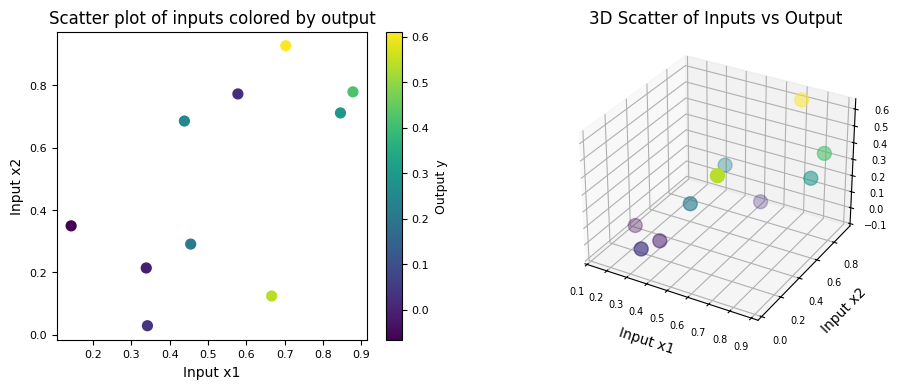

In [3]:
plot_data_exploration(data)

**Observations:**
- The highest initial value is 0.611205 at [0.702637, 0.926564].
- The second-highest initial value is 0.538996 at [0.665800, 0.123969].
- These two observations suggest separated upper and lower candidate regions.

**Interpretation:** With only 10 observations, neither region can yet be treated as a confirmed local optimum. The initial evidence therefore supports broad exploration rather than immediately concentrating all subsequent evaluations around one point.

<h1 style="color:#0000CD;font-size:19px;">2. Phase 1: Global exploration (Weeks 1-4)</h1>

**2.1 - RBF GP and UCB**

The first 4 queries use:
- **candidate set:** a $50^2$ global cartesian grid;
- **surrogate:** a Gaussian Process (GP) with a Radial Basis Function (RBF) kernel and a fixed length scale $l=0.2$
- **acquisition:** Upper Confidence Bound (UCB) with a starting $\kappa=1.5$.

The length scale is initially fixed to control smoothness while the data are still sparse; larger values imply smoother fits.<br>
The search keeps $\kappa=1.5$ for Weeks 1–3. Week 3 produces a new best value at the lower boundary, so Week 4 deliberately increases $\kappa$ to **2.25** for one broader exploration query before narrowing the search.

In [4]:
# Candidates points Grid
X_grid_50 = cartesian_grid(dimension=2,points_per_axis=50) 

# RBF Kernel
rbf_fixed_kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)

# Kappa schedule 
phase_1_kappa_schedule = [(1,1.50),(2, 1.50), (3, 1.50), (4,2.25)]
phase_1_rows = []
phase_1_ucbs = []

for week, kappa in phase_1_kappa_schedule:
    
    inputs, outputs = extract(data)

    proposed_point, ucb_values = run_search_strategy(
        inputs,
        outputs,
        X_grid_50,
        rbf_fixed_kernel,
        upper_confidence_bound,
        kappa=kappa)

    queried_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_1_rows.append({
        "week": week,
        "kappa": kappa,
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(proposed_point, queried_point, atol=1e-6),
        "improved_incumbent": observed_y > outputs.max()})

    phase_1_ucbs.append(ucb_values)

    data = update_data(data,queried_point,observed_y)

inputs, outputs = extract(data)
phase_1_history = pd.DataFrame(phase_1_rows)
display(phase_1_history)

Point added!
Point added!
Point added!
Point added!


,week,kappa,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,1,1.50,0.816327,1.000000,0.816327,1.000000,-0.012804,True,False
1,2,1.50,0.755102,0.142857,0.755102,0.142857,0.331094,True,False
2,3,1.50,0.714286,0.000000,0.714286,0.000000,0.612394,True,True
3,4,2.25,0.836735,0.000000,0.836735,0.000000,0.062186,True,False


**2.2. Visual Exploration**

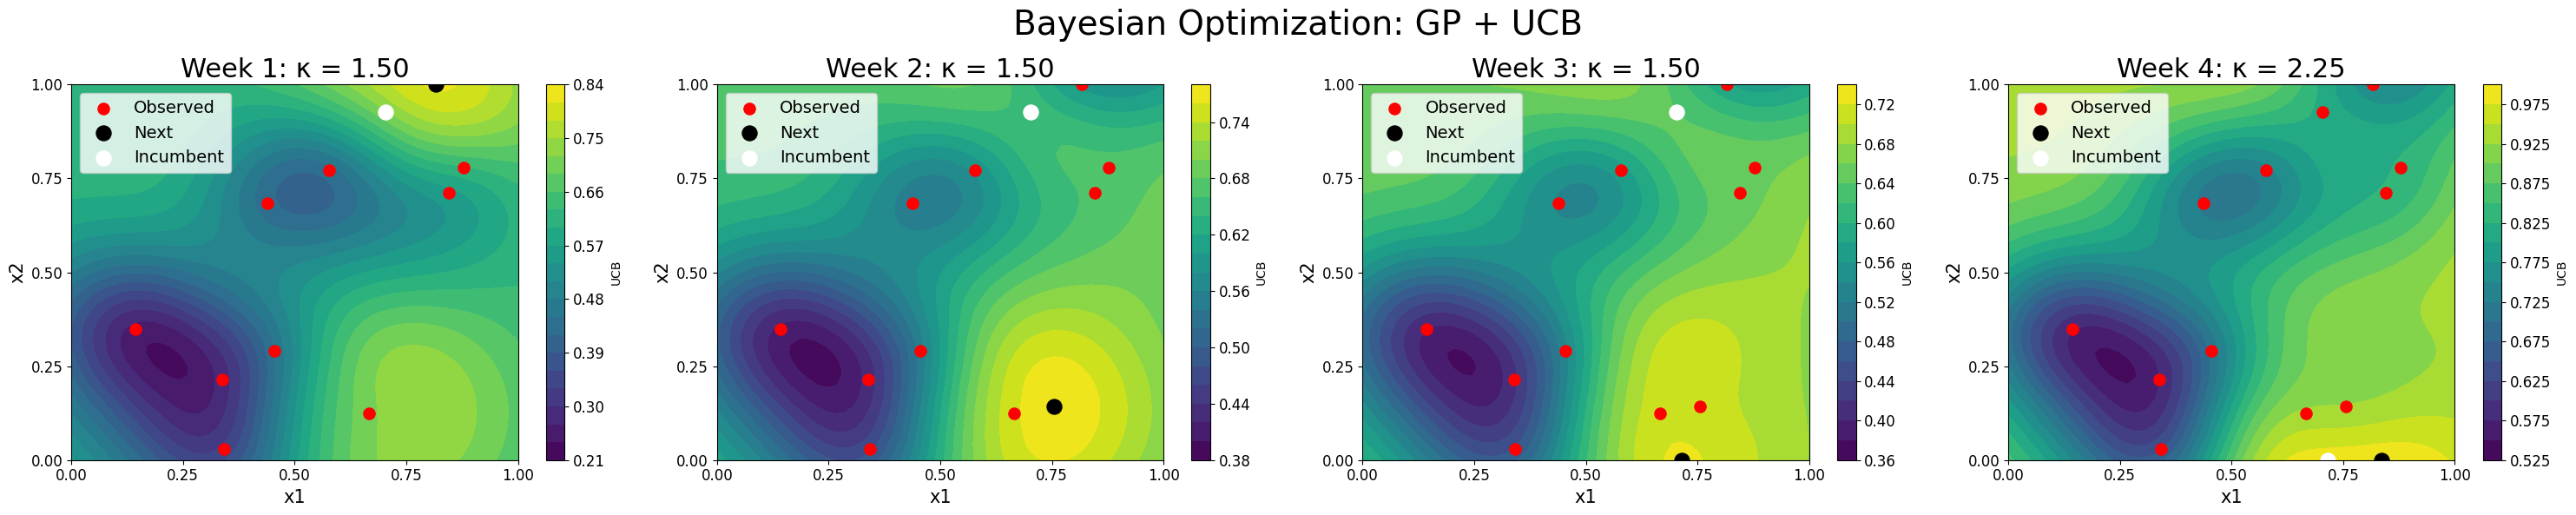

In [5]:
fig, axes = plt.subplots(1,4, figsize=(30, 6))

for week, ax  in enumerate(axes, start=1):

    week_data = data[:10 + week - 1]
    week_inputs, week_outputs = extract(week_data)
    week_incumbent = week_inputs[np.argmax(week_outputs)]
    week_candidate = np.array([phase_1_rows[week - 1]["candidate_x1"],phase_1_rows[week - 1]["candidate_x2"]])
    
    plot_acquisition_2d(X_grid_50, phase_1_ucbs[week-1], week_data, week_incumbent, week_candidate , "UCB", ax=ax)
    ax.set_title(f"Week {week}: κ = {phase_1_kappa_schedule[week - 1][1]:.2f}", fontsize=22)

fig.suptitle(f'Bayesian Optimization: GP + UCB', fontsize=28) 
plt.tight_layout()
plt.show()

**Phase result and transition:** 
Week 3 improves the initial best from **0.611205** to **0.612394** at **[0.714286, 0.000000]**. This makes the lower boundary a credible region rather than only an isolated high initial observation.

The higher-$\kappa$ Week 4 query returns **0.062186**, providing little support for spending further budget on broad uncertainty-driven exploration. The next phase therefore concentrates resolution around the two high-value regions already supported by observations.


<h1 style="color:#0000CD;font-size:19px;">3. Phase 2: High-resolution acquisition search (Week 5-8)</h1>

**3.1 - Exploratory Diagnostics: GP Posterior Mean Surface vs Thin Plate RBF visualisation**

Before selecting the Week 5 candidate, the observed surface is inspected using two complementary visual diagnostics. The objective is to determine whether the strongest observations from Phase 1 belong to broader regions worth examining at higher resolution.

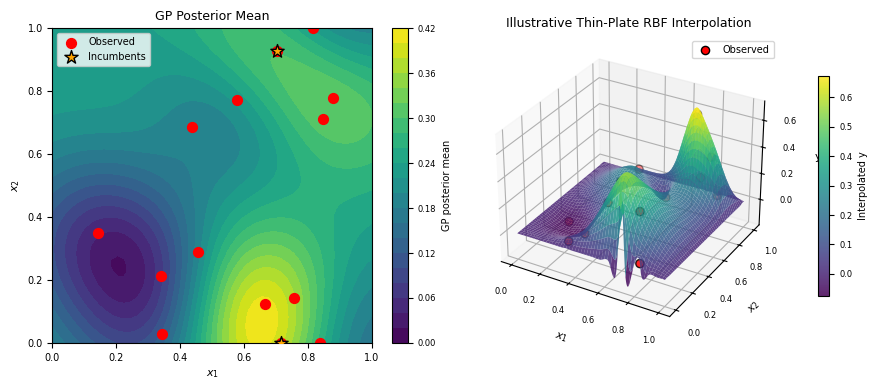

In [6]:
kernel = RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)
gp.fit(inputs, outputs)
mu, sigma = gp.predict(X_grid_50, return_std=True)
plot_surrogate_landscapes(X_grid_50, mu, data)

**On the left:** A contour plot of the Gaussian Process posterior mean visualises the surrogate model's predicted objective landscape across the full two-dimensional domain. This highlights regions where the GP currently assigns relatively high expected function values, independently of posterior uncertainty.

**On the right:** A thin-plate radial basis function interpolation provides an alternative exploratory representation of how the observed values may connect across the domain. Synthetic low-valued boundary control points are added solely to reduce uncontrolled edge extrapolation and improve visual stability near the domain boundaries. These points are not observations and are not included in the Gaussian Process fit or in any acquisition-function calculations.

Both visualisations suggest two regions for more concentrated follow-up search:

- a lower region around $x_1\in[0.60,0.75]$, $x_2\in[0.00,0.15]$;
- an upper region around $x_1\in[0.65,0.90]$, $x_2\in[0.65,1.00]$.

The agreement between the two surfaces provides qualitative support for prioritising these regions, but is not treated as evidence of the true geometry of Function 2. The diagnostics are used only to guide the next search decision.

**3.2 - Next candidates selection (Week 5)**

- Week 5 increases candidate resolution to $500^2$ and restricts the candidate set to the two empirical high-value regions described above, and reduces $\kappa$ to **0.25**.
- Weeks 6–8 then return to the full $500^2$ domain with **Expected Improvement** (EI).

This separates two questions:
1. can tighter exploitation of the observed regions improve the best value?
2. if not, does higher-resolution full-domain improvement search reveal a better distant region?

In [7]:
# Increase the resolution of Candidate points (grid)
X_grid_500 = cartesian_grid(2, 500)

# Mask limiting area of search
grid = X_grid_500
mask = (((grid[:, 0] >= 0.60) & (grid[:, 0] <= 0.75) & (grid[:, 1] >= 0.00) & (grid[:, 1] <= 0.15)) | ((grid[:, 0] >= 0.65) & (grid[:, 0] <= 0.90) & (grid[:, 1] >= 0.65) & (grid[:, 1] <= 1.00)))
X_grid_constrained = X_grid_500[mask]

print(f"Full 500² grid: {len(X_grid_500):,} candidates")
print(f"Week 5 constrained set: {len(X_grid_constrained):,} candidates")

Full 500² grid: 250,000 candidates
Week 5 constrained set: 27,500 candidates


In [8]:
# Schedule for acquisition parameters
phase_2_acquisition_schedule = [(5, X_grid_constrained, "Constrained grid", upper_confidence_bound), 
                                (6, X_grid_500, "500 × 500 grid", expected_improvement),
                                (7, X_grid_500, "500 × 500 grid", expected_improvement),
                                (8, X_grid_500, "500 × 500 grid", expected_improvement)]
phase_2_rows = []
phase_2_acquisitions = []

for week, candidate_grid, grid_label, acquisition_fn in phase_2_acquisition_schedule:
    
    inputs, outputs = extract(data)

    if acquisition_fn is upper_confidence_bound:
        acquisition_label = "UCB"
        acquisition_kwargs = {"kappa": 0.25}
    else:
        acquisition_label = "EI"
        acquisition_kwargs = {"best": outputs.max()}

    proposed_point, acquisition_values = run_search_strategy(
        inputs,
        outputs,
        candidate_grid,
        rbf_fixed_kernel,
        acquisition_fn,
        **acquisition_kwargs)

    queried_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_2_rows.append({
        "week": week,
        "search_space": grid_label,
        "acquisition": acquisition_label,
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(proposed_point, queried_point, atol=1e-6),
        "improved_incumbent": observed_y > outputs.max()})

    phase_2_acquisitions.append(acquisition_values)
    data = update_data(data, queried_point, observed_y)

inputs, outputs = extract(data)
phase_2_history = pd.DataFrame(phase_2_rows)
display(phase_2_history)


Point added!
Point added!
Point added!
Point added!


,week,search_space,acquisition,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,5,Constrained grid,UCB,0.651303,0.060120,0.653266,0.045226,0.377662,False,False
1,6,500 × 500 grid,EI,0.629259,0.000000,0.629259,0.000000,0.265357,True,False
2,7,500 × 500 grid,EI,0.697395,0.254509,0.697395,0.254509,0.579392,True,False
3,8,500 × 500 grid,EI,0.711423,0.296593,0.711423,0.296593,0.501180,True,False


**Reproducibility note.** The reconstructed Week 5 constrained-UCB maximiser is close to, but not identical to, the recorded submitted point. The notebook therefore keeps the recorded point as the historical observation rather than silently replacing it with the reconstructed recommendation.

- Week 5 deliberately restricts the search to the two regions identified by the exploratory diagnostics<br>
- Weeks 6–8 subsequently return to full-domain search.

**3.3. Full domain EI visualisation**

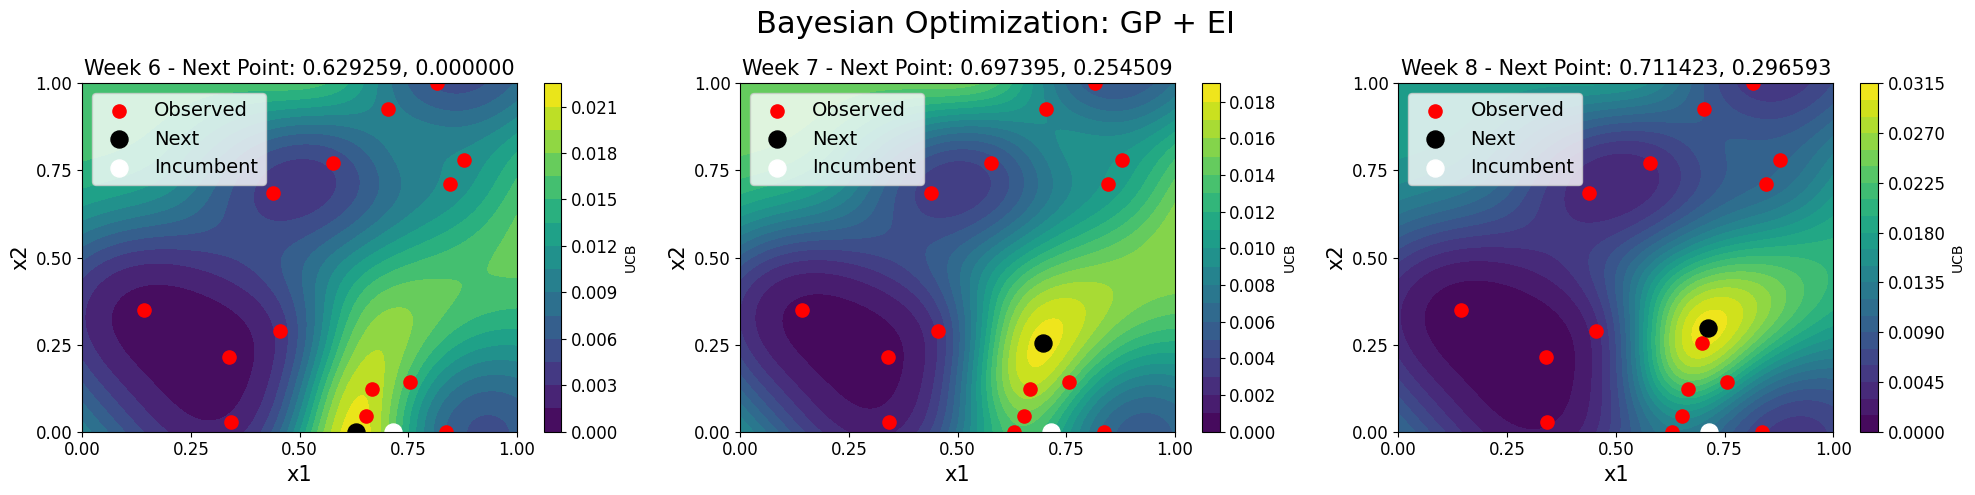

In [9]:
fig, axes = plt.subplots(1,3, figsize=(20, 5))

for week, ax  in enumerate(axes, start=6):

    week_data = data[:10 + week - 1]
    week_inputs, week_outputs = extract(week_data)
    week_incumbent = week_inputs[np.argmax(week_outputs)]
    week_candidate = np.array([phase_2_rows[week - 5]["candidate_x1"],phase_2_rows[week - 5]["candidate_x2"]])
    week_label = phase_2_rows[week-5]["acquisition"]
    
    plot_acquisition_2d(X_grid_500, phase_2_acquisitions[week-5], week_data, week_incumbent, week_candidate , week_label, ax=ax)
    ax.set_title(f"Week {week} - Next Point: {week_candidate[0]:.6f}, {week_candidate[1]:.6f}", fontsize=15)

fig.suptitle(f'Bayesian Optimization: GP + EI', fontsize=22) 
plt.tight_layout()
plt.show()

**Phase 2 result:** None of Weeks 5–8 improves the Week 3 best value. Week 7 still returns a comparatively strong **0.579392**, but repeated higher-resolution global search does not uncover a better distant basin.

The evidence now favours a different question. The lower region contains several strong observations, including the best point directly on $x_2=0$, while small coordinate changes can produce much weaker values. Rather than spend another query on unrestricted acquisition maximisation, the next phase tests the local geometry directly.

<h1 style="color:#0000CD;font-size:19px;">4. Phase 3: Local diagnosis and probabilistic refinement (Weeks 9–12)</h1>

**4.1 - Directional diagnostics (Weeks 9–10)**

- Week 9 is an **inward boundary probe**: keep $x_1=0.714286$ fixed and move from $x_2=0$ to $x_2=0.025$. This tests whether the strong boundary value improves immediately inside the feasible domain.

- Week 10 then makes a **diagonal sensitivity probe**, decreasing $x_1$ by $0.0125$ and increasing $x_2$ by $0.0125$. This tests whether the Week 9 improvement extends in that direction.

These two points are researcher-selected diagnostics rather than acquisition-function outputs.

In [10]:
phase_3_directional_probes = [ (9,  [0.714286, 0.025000], "inward x2-boundary probe" ),
                               (10, [0.701786, 0.037500], "north-west diagonal probe") ]
phase_3_rows = []

for week, proposed_point, rationale in phase_3_directional_probes:
    
    inputs, outputs = extract(data)
    previous_best = outputs.max()
    queried_point, observed_y = historical_record(FUNCTION_ID,week)

    phase_3_rows.append({
        "week": week,
        "diagnostic": rationale,
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(proposed_point, queried_point, atol=1e-6),
        "improved_incumbent": observed_y > previous_best})

    data = update_data(data, queried_point, observed_y)

inputs, outputs = extract(data)
phase_3_history = pd.DataFrame(phase_3_rows)
display(phase_3_history)

Point added!
Point added!


,week,diagnostic,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,9,inward x2-boundary probe,0.714286,0.0250,0.714286,0.0250,0.632404,True,True
1,10,north-west diagonal probe,0.701786,0.0375,0.701786,0.0375,0.515447,True,False


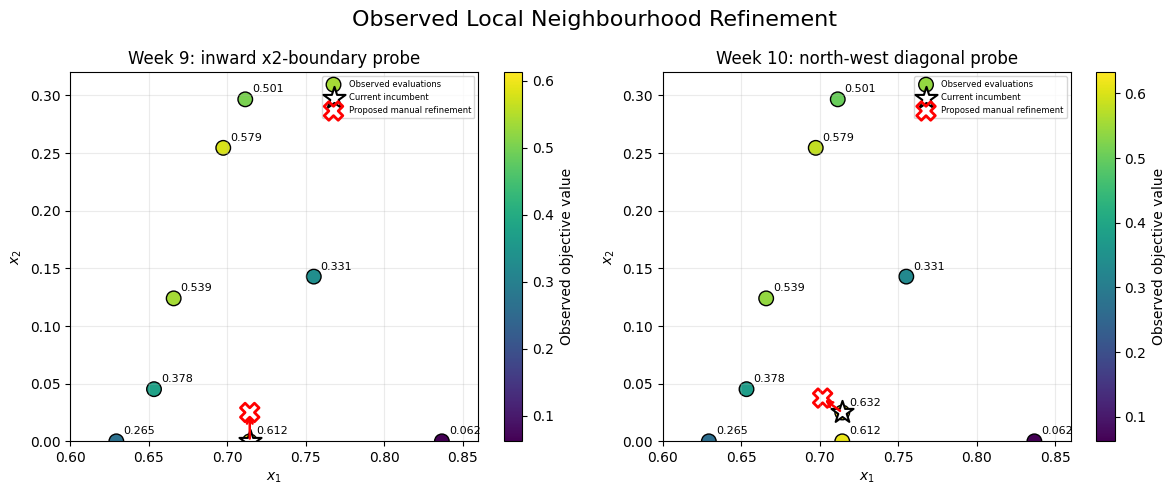

In [11]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))

for week, ax  in enumerate(axes, start=9):

    week_data = data[:10 + week - 1]
    week_inputs, week_outputs = extract(week_data)
    week_incumbent = week_inputs[np.argmax(week_outputs)]
    week_candidate = np.array([phase_3_rows[week - 9]["candidate_x1"],phase_3_rows[week - 9]["candidate_x2"]])

    plot_local_refinement_2d(
        data=week_data,
        incumbent=week_incumbent,
        candidate=week_candidate,
        title=f"Week {week}: {phase_3_rows[week -9]["diagnostic"]}",
        ax=ax)
    
fig.suptitle(f'Observed Local Neighbourhood Refinement', fontsize=16) 
plt.tight_layout()
plt.show()

**Directional evidence.** 
- Week 9 improves the best value to **0.632404**. The lower-boundary signal is therefore not simply an edge artefact: a stronger point exists immediately inside the domain.
- Week 10 then falls to **0.515447**. This does not locate the local maximum, but it argues against a simple continuation toward **lower $x_1$ and higher $x_2$**.

That directional evidence is used explicitly in the next model-based search rather than discarded.

**4.2 - Local Matérn-PI refinement (Weeks 11–12)**

The search now returns to a probabilistic model, but only in the neighbourhood of the Week 9 best point. A Matérn-5/2 kernel is used because the observed local response changes materially over small coordinate moves. PI uses the remaining model-based budget to search specifically for an improvement, while a minimum distance of **0.005** prevents near-duplicate candidates.

The local window changes for a reason:

- **Week 11:** after the poor Week 10 move toward lower $x_1$, the search is asymmetric and does not extend below the best observed $x_1$.
- **Week 12:** Week 11 returns a strong value at higher $x_2$ but does not improve the best value. The $x_1$ window is therefore reopened symmetrically to test whether Week 10 failed because of that particular diagonal direction rather than because every lower-$x_1$ point is poor.

In [12]:
# Matérn 5/2 Kernel 
matern_52_kernel = ConstantKernel(1.0)* Matern(length_scale=np.array([0.02, 0.02]), nu=2.5) + WhiteKernel(noise_level=1e-10)

phase_3_local_windows = {
    11: { "radius": np.array([0.00, 0.10]),
          "upper_radius": np.array([0.20, 0.10]),
          "window": "PI asymmetric window"},
    
    12: { "radius": np.array([0.10, 0.10]),
          "upper_radius": None,
          "window": "PI symmetric window"}}

phase_3_local_snapshots = {}
phase_3_local_candidates = {}

for week in (11, 12):
    
    inputs, outputs = extract(data)
    x_best, y_best = (inputs[np.argmax(outputs)], outputs.max())
    phase_3_local_snapshots[week] = data.copy()

    gp = GaussianProcessRegressor(kernel=matern_52_kernel, alpha=1e-12, normalize_y=True, n_restarts_optimizer=20, random_state=RANDOM_SEED)
    gp.fit(inputs, outputs)
    spec = phase_3_local_windows[week]
    
    if spec["upper_radius"] is None:
        lower, upper = search_region(x_best, radius=spec["radius"])
    else:
        lower, upper = search_region(x_best, radius=spec["radius"],upper_radius=spec["upper_radius"])

    X_local = cartesian_grid(dimension=2, points_per_axis=1000, lower=lower, upper=upper)
    X_candidates = filter_candidates(X_local, inputs, min_distance=0.005)

    mu, sigma = gp.predict(X_candidates, return_std=True)
    pi = probability_of_improvement( mu, sigma, best=y_best, xi=0.0)
    proposed_point = X_candidates[np.argmax(pi)]
    phase_3_local_candidates[week] = proposed_point.copy()

    queried_point, observed_y = historical_record(FUNCTION_ID, week)

    phase_3_rows.append({
        "week": week,
        "diagnostic": spec["window"],
        "candidate_x1": proposed_point[0],
        "candidate_x2": proposed_point[1],
        "recorded_x1": queried_point[0],
        "recorded_x2": queried_point[1],
        "observed_y": observed_y,
        "matches_record": np.allclose(proposed_point, queried_point, atol=1e-6),
        "improved_incumbent": observed_y > y_best})

    data = update_data(data, queried_point, observed_y)

inputs, outputs = extract(data)
phase_3_history = pd.DataFrame(phase_3_rows)
display(phase_3_history)

Point added!
Point added!


,week,diagnostic,candidate_x1,candidate_x2,recorded_x1,recorded_x2,observed_y,matches_record,improved_incumbent
0,9,inward x2-boundary probe,0.714286,0.0250,0.714286,0.0250,0.632404,True,True
1,10,north-west diagonal probe,0.701786,0.0375,0.701786,0.0375,0.515447,True,False
2,11,PI asymmetric window,0.714286,0.1250,0.714286,0.1250,0.613833,True,False
3,12,PI symmetric window,0.704977,0.0000,0.704977,0.0000,0.498144,True,False


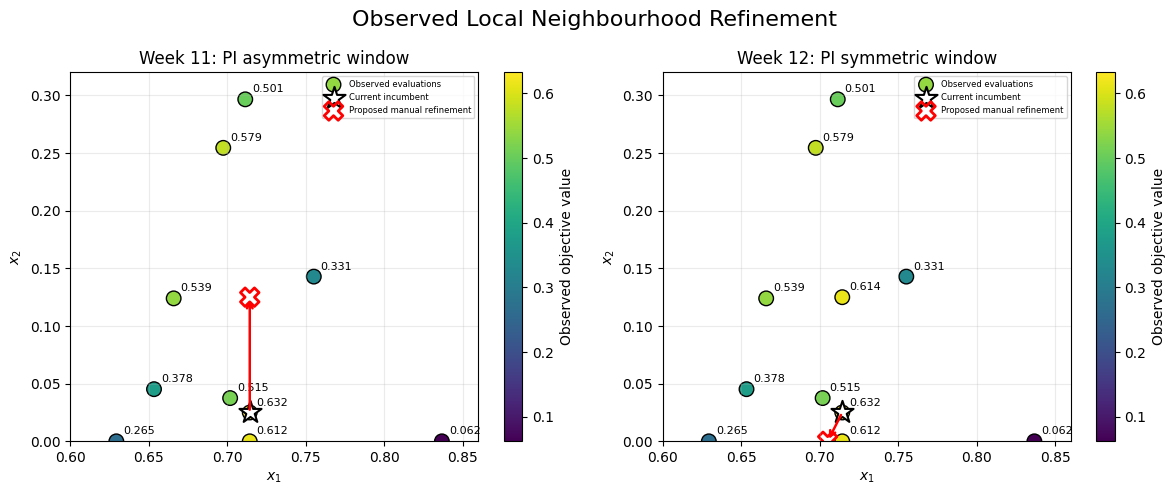

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))

for week, ax  in enumerate(axes, start=11):

    week_data = data[:10 + week - 1]
    week_inputs, week_outputs = extract(week_data)
    week_incumbent = week_inputs[np.argmax(week_outputs)]
    week_candidate = np.array([phase_3_rows[week - 9]["candidate_x1"],phase_3_rows[week - 9]["candidate_x2"]])

    plot_local_refinement_2d(
        data=week_data,
        incumbent=week_incumbent,
        candidate=week_candidate,
        title=f"Week {week}: {phase_3_rows[week -9]["diagnostic"]}",
        ax=ax)
    
fig.suptitle(f'Observed Local Neighbourhood Refinement', fontsize=16) 
plt.tight_layout()
plt.show()

**Local refinement result:** 
- Week 11 returns **0.613833 at [0.714286, 0.125000]**: below the Week 9 best, but still strong while keeping $x_1$ fixed.
- Week 12 then returns **0.498144 at [0.704977, 0.000000]**. Together with Week 10, this gives additional evidence that moving materially below $x_1\approx0.714$ is not promising in the tested neighbourhood.

The best observed point remains **[0.714286, 0.025000]**. The final query therefore keeps $x_1$ fixed and tests the unresolved behaviour along $x_2$.

<h1 style="color:#0000CD;font-size:19px;">5. Phase 4: Final vertical-slice diagnostic (Week 13)</h1>

At fixed $x_1=0.714286$, three observations are already available:

- $x_2=0.000000 \rightarrow 0.612394$
- $x_2=0.025000 \rightarrow 0.632404$
- $x_2=0.125000 \rightarrow 0.613833$

The final point, **[0.714286, 0.062500]**, probes the interior of this vertical slice. It tests whether the strong values form a broad high-value segment in $x_2$ or whether the local response is substantially sharper or non-monotonic.

Recorded Week 13 point: [0.714286 0.0625  ]
Observed value: 0.543542953
Candidate matches record: True
Point added!


,x1,x2,y
0,0.714286,0.0000,0.612394
1,0.714286,0.0250,0.632404
2,0.714286,0.0625,0.543543
3,0.714286,0.1250,0.613833


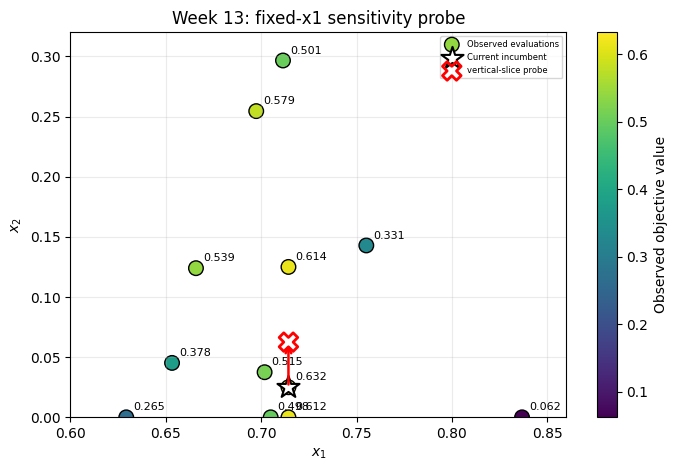

In [14]:
inputs, outputs = extract(data)
week_13_snapshot = data.copy()
week_13_best = inputs[np.argmax(outputs)]
week_13_candidate = np.array([0.714286, 0.062500])

plot_local_refinement_2d(
    data=week_13_snapshot,
    incumbent=week_13_best,
    candidate=week_13_candidate,
    candidate_label="vertical-slice probe",
    title="Week 13: fixed-x1 sensitivity probe")

queried_point, observed_y = historical_record(FUNCTION_ID, 13)

print("Recorded Week 13 point:", queried_point)
print("Observed value:", observed_y)
print("Candidate matches record:", np.allclose(week_13_candidate, queried_point, atol=1e-6))

data = update_data(data, queried_point, observed_y)
inputs, outputs = extract(data)

vertical_slice = (
    data[np.isclose(data["x1"], 0.714286, atol=1e-6)][["x1", "x2", "y"]]
    .sort_values("x2")
    .reset_index(drop=True))
display(vertical_slice)

**Final observed solution.** Week 13 returns **0.543543**, materially below the neighbouring values at $x_2=0.025$ and $x_2=0.125$. The observed vertical slice is therefore not consistent with a simple broad smooth ridge in $x_2$.

The best observed configuration remains **[0.714286, 0.025000]** with **$y=0.632404$**. This is the best point found under the available query budget, not proof of the global maximum.

<h1 style="color:#0000CD;font-size:19px;">6. Quantitative Evaluation</h1>

The retrospective evaluation addresses four questions:

1. **Performance:** did the 13 sequential queries improve the best observed value?
2. **Surrogate robustness:** how sensitive are predictive conclusions to the GP specification?
3. **Early-search sensitivity:** how sensitive was the initial RBF surrogate to the fixed length scale, and how stable was the Week 1 recommendation to UCB $\kappa$ and grid resolution?
4. **Matérn stability:** did the Week 11–12 recommendations depend on the Matérn starting length scale?

These diagnostics assess the robustness of the historical search; they do not establish global optimality or a counterfactual against another optimisation policy.

**6.1 - Sequential and query-budget performance**

The best-so-far value tracks the direct improvement achieved by the 13-query budget.

,metric,value
0,Initial incumbent,0.611205
1,Final best observed,0.632404
2,Absolute improvement,0.021199
3,Relative improvement,3.47%
4,Queries improving incumbent,2


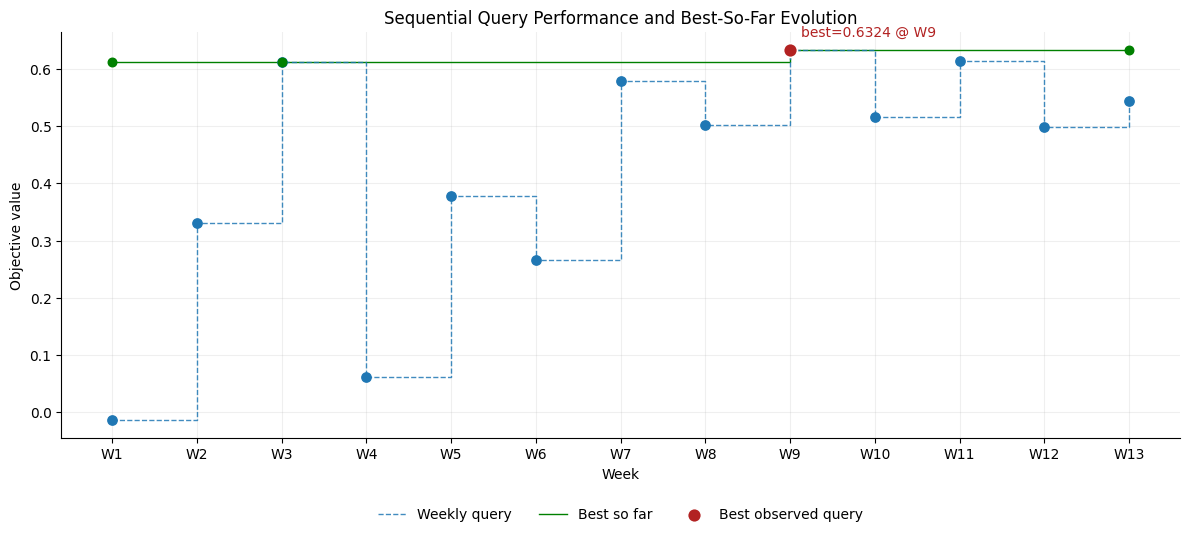

In [15]:
performance, performance_summary = sequential_performance(
    initial_outputs=outputs[:10],
    query_outputs=outputs[10:])

summary_display = performance_summary.copy()
summary_display["value"] = [
    f"{performance_summary.loc[0, 'value']:.6f}",
    f"{performance_summary.loc[1, 'value']:.6f}",
    f"{performance_summary.loc[2, 'value']:.6f}",
    f"{performance_summary.loc[3, 'value']:.2%}",
    f"{int(performance_summary.loc[4, 'value'])}"]

display(summary_display)

plot_sequential_query_performance(
    performance,
    FUNCTION_ID,
    yscale="linear",
    plot_type="bar")

**Interpretation:** The best observed value increases from **0.611205** to **0.632404**, an improvement of approximately **3.47%**. Only **2 of the 13** sequential evaluations improve the incumbent directly: Week 3 during global exploration and Week 9 during the targeted inward-boundary diagnostic.

The late-stage contribution should therefore not be judged only by the number of incumbent improvements. Once repeated global acquisition searches stopped improving the best value, the local experiments were used to test the geometry of the promising region directly. The largest late-stage improvement came from the researcher-designed Week 9 inward-boundary probe.

**6.2 - Surrogate robustness**

The complete dataset is compared under three GP specifications:

- the historical **fixed RBF**;
- a **fitted RBF control**, which keeps the RBF family but allows the length scale to adapt;
- the **Matérn-5/2** specification used in the later local search.

The fitted RBF separates sensitivity to the fixed RBF length-scale assumption from broader sensitivity to the surrogate specification.

- **LOOCV RMSE:** lower is better.
- **Spearman correlation:** higher means better preservation of the observed ranking.

In [16]:
predictive_kernels = {
    "RBF_fixed": RBF(length_scale=0.2, length_scale_bounds="fixed") + WhiteKernel(noise_level=1e-6),
    "RBF_fitted_bounded": RBF(length_scale=0.2, length_scale_bounds=(0.05, 1.0)) + WhiteKernel(noise_level=1e-6),
    "Matern_52": ConstantKernel(1.0)* Matern(length_scale=np.array([0.02, 0.02]), nu=2.5) + WhiteKernel(noise_level=1e-10)}

surrogate_robustness = kernel_choice_validation(
    inputs,
    outputs,
    predictive_kernels,
    alpha=1e-10,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=RANDOM_SEED)

display(surrogate_robustness)

,kernel,LOOCV_RMSE,Spearman_rank_correlation
0,RBF_fixed,0.245174,0.131423
1,RBF_fitted_bounded,0.223547,0.438735
2,Matern_52,0.200138,0.577075


**Interpretation:** The fitted RBF improves on the fixed RBF, showing that predictive performance is sensitive to the historical fixed smoothness assumption. Matérn-5/2 nevertheless performs best among the tested specifications, with the lowest LOOCV RMSE and highest Spearman correlation.

The improvement from fitted RBF to Matérn-5/2 suggests that the result is not explained only by allowing the length scale to adapt. However, rank agreement remains moderate, so this remains a retrospective robustness diagnostic rather than evidence that the hidden function has been accurately reconstructed.

Because the comparison uses the complete dataset, it does not imply that Matérn-5/2 should necessarily have been selected at the start of the experiment.

**6.3 - Early-search sensitivity**

The Week 1 RBF-UCB decision depended on three researcher-controlled choices:

- fixed RBF length scale;
- UCB exploration parameter $\kappa$;
- Cartesian-grid resolution.

The following checks assess whether reasonable alternatives would materially change the model interpretation or recommended region.

**6.3.1 - Fixed RBF length-scale sensitivity**

The historical RBF used a fixed length scale of $\ell=0.20$. A small set of alternative values is tested on the initial 10 observations to assess how dependent predictive performance is on this smoothness assumption.

In [17]:
def initial_rbf_kernel(length_scale):
    return build_kernel("rbf", inputs[:10].shape[1], length_scale, "fixed")

initial_length_scale_sensitivity = fixed_length_scale_validation(
    inputs[:10],
    outputs[:10],
    kernel_factory=initial_rbf_kernel,
    length_scales=[0.05, 0.10, 0.20, 0.40],
    alpha=1e-10,
    normalize_y=True)

display(initial_length_scale_sensitivity)


,length_scale,LOOCV_RMSE,Spearman_rank_correlation
0,0.05,0.247084,-0.672727
1,0.10,0.238991,-0.127273
2,0.20,0.254748,0.103030
3,0.40,0.231471,0.454545


**Interpretation:** The early RBF surrogate is materially sensitive to the assumed smoothness.

The historical choice $\ell=0.20$ does not minimise LOOCV RMSE and provides only weak positive rank preservation on the initial observations. Among the tested values, $\ell=0.40$ performs better on both metrics, with lower prediction error and substantially stronger Spearman correlation.

This does **not** establish $\ell=0.40$ as the true or optimal length scale. With only 10 initial observations, the covariance structure is weakly identified. The result instead shows that the geometry implied by the early fixed-RBF surrogate should be interpreted cautiously.

The historical $\ell=0.20$ model is therefore best understood as a controlled search model under sparse information rather than a definitive representation of Function 2.

**6.3.2 - UCB exploration sensitivity**

Week 1 used $\kappa=1.5$. Holding the GP and $50^2$ grid fixed, nearby $\kappa$ values are tested to determine whether the exploration–exploitation choice materially changes the recommended location.

In [18]:
# Reconstruct the historical Week 1 GP
week_1_gp = GaussianProcessRegressor(kernel=rbf_fixed_kernel, alpha=1e-10, normalize_y=True)
week_1_gp.fit(inputs[:10], outputs[:10])
mu_50, sigma_50 = week_1_gp.predict(X_grid_50, return_std=True)

kappa_points = {}

for kappa in [1.0, 1.5, 2.0, 2.25, 2.5]:

    ucb = upper_confidence_bound(mu_50, sigma_50, kappa=kappa)
    kappa_points[kappa] = X_grid_50[np.argmax(ucb)]

historical_candidate = kappa_points[1.5]

kappa_sensitivity = pd.DataFrame([
    { "kappa": kappa,
      "candidate_x1": candidate[0],
      "candidate_x2": candidate[1],
      "distance_from_kappa_1.5": np.linalg.norm(candidate - historical_candidate)}
    for kappa, candidate in kappa_points.items()])

display(kappa_sensitivity)

,kappa,candidate_x1,candidate_x2,distance_from_kappa_1.5
0,1.00,0.816327,1.0,0.000000
1,1.50,0.816327,1.0,0.000000
2,2.00,0.836735,1.0,0.020408
3,2.25,0.857143,1.0,0.040816
4,2.50,0.857143,1.0,0.040816


**Interpretation:** The Week 1 recommendation is qualitatively stable across the tested $\kappa$ values. The precise coordinate moves, but the candidates remain in the same broad region.

The historical $\kappa=1.5$ therefore does not appear to be a fragile threshold determining the direction of the search.

**6.3.3 - Cartesian-grid resolution sensitivity**

The historical Week 1 acquisition was maximised over a $50^2$ grid. The same GP and $\kappa=1.5$ are evaluated at alternative resolutions to test whether the selected region depends on discretisation.

In [19]:
grid_sensitivity = cartesian_resolution_sensitivity(
    gp=week_1_gp,
    dimension=2,
    resolutions=[25, 50, 100, 500],
    acquisition="UCB",
    best=float(np.max(outputs[:10])),
    kappa=1.5)

# Separate candidate coordinates for readability
grid_sensitivity[
    ["candidate_x1", "candidate_x2"]
] = pd.DataFrame(
    grid_sensitivity["candidate"].tolist(),
    index=grid_sensitivity.index)

# Historical 50² recommendation
reference_candidate = np.array(
    grid_sensitivity.loc[
        grid_sensitivity["resolution"] == 50,
        "candidate",
    ].iloc[0])

grid_sensitivity["distance_from_50_grid"] = (
    grid_sensitivity["candidate"].apply(
        lambda candidate:
        np.linalg.norm(np.array(candidate) - reference_candidate)))

display(
    grid_sensitivity[
        [   "resolution",
            "n_candidates",
            "candidate_x1",
            "candidate_x2",
            "distance_from_50_grid"]])

,resolution,n_candidates,candidate_x1,candidate_x2,distance_from_50_grid
0,25,625,0.833333,1.0,0.017007
1,50,2500,0.816327,1.0,0.000000
2,100,10000,0.828283,1.0,0.011956
3,500,250000,0.825651,1.0,0.009325


**Interpretation.** Increasing grid resolution changes the precise coordinate but not the broad recommended region.

The historical $50^2$ grid therefore appears sufficiently fine for the qualitative Week 1 decision, although this does not imply that the same resolution is sufficient at every stage of the experiment.

**6.4 - Matérn initialisation stability**

Weeks 11–12 used a Matérn-5/2 GP initialised at $[0.02,0.02]$, with the length scales subsequently fitted using multiple optimiser restarts.

Alternative starting values are tested to determine whether the fitted model or PI recommendation materially depends on this initialisation.

In [20]:
matern_initialisations = [
    np.array([0.01, 0.01]),
    np.array([0.02, 0.02]),   # historical
    np.array([0.05, 0.05]),
    np.array([0.10, 0.10])]

matern_stability_rows = []

for week in [11, 12]:

    # Observations available immediately before this week's query
    week_inputs = inputs[:10 + week - 1]
    week_outputs = outputs[:10 + week - 1]

    best_idx = np.argmax(week_outputs)
    x_best = week_inputs[best_idx]
    y_best = week_outputs[best_idx]

    # Reproduce historical search window
    if week == 11:
        lower, upper = search_region(x_best, radius=np.array([0.00, 0.10]), upper_radius=np.array([0.20, 0.10]))
    else:
        lower, upper = search_region(x_best, radius=np.array([0.10, 0.10]))

    X_local = cartesian_grid(dimension=2,points_per_axis=1000, lower=lower, upper=upper)
    X_candidates = filter_candidates(X_local,week_inputs,min_distance=0.005)

    for initial_scale in matern_initialisations:

        kernel = (ConstantKernel(1.0)* Matern(length_scale=initial_scale, nu=2.5)+ WhiteKernel(noise_level=1e-10))

        gp = GaussianProcessRegressor(kernel=kernel,alpha=1e-12,normalize_y=True,n_restarts_optimizer=20, random_state=RANDOM_SEED)
        gp.fit(week_inputs, week_outputs)
        mu, sigma = gp.predict(X_candidates,return_std=True)

        pi = probability_of_improvement(mu,sigma,best=y_best,xi=0.0)
        candidate = X_candidates[np.argmax(pi)]

        fitted_scale = np.atleast_1d(gp.kernel_.k1.k2.length_scale)

        matern_stability_rows.append({
            "week": week,
            "initial_scale": initial_scale.tolist(),
            "fitted_scale_x1": fitted_scale[0],
            "fitted_scale_x2": fitted_scale[1],
            "candidate_x1": candidate[0],
            "candidate_x2": candidate[1],
            "log_marginal_likelihood": gp.log_marginal_likelihood_value_})

matern_initialisation_stability = pd.DataFrame( matern_stability_rows)

display(matern_initialisation_stability)

,week,initial_scale,fitted_scale_x1,fitted_scale_x2,candidate_x1,candidate_x2,log_marginal_likelihood
0,11,"[0.01, 0.01]",0.065092,13085.602055,0.714286,0.125,-17.356393
1,11,"[0.02, 0.02]",0.065093,18121.752361,0.714286,0.125,-17.356393
2,11,"[0.05, 0.05]",0.065093,4126.789110,0.714286,0.125,-17.356393
3,11,"[0.1, 0.1]",0.065097,7738.006269,0.714286,0.125,-17.356393
4,12,"[0.01, 0.01]",0.066721,1938.115696,0.704977,0.000,-17.107623
5,12,"[0.02, 0.02]",0.066721,1938.115696,0.704977,0.000,-17.107623
6,12,"[0.05, 0.05]",0.066721,1938.115696,0.704977,0.000,-17.107623
7,12,"[0.1, 0.1]",0.066721,1938.115696,0.704977,0.000,-17.107623


**Interpretation:** The Week 11–12 PI recommendations are stable across the tested Matérn initialisations. Although the fitted $x_2$ length scale varies substantially for Week 11, the log-marginal likelihood and recommended candidate remain effectively unchanged. This suggests that the $x_2$ length scale is weakly identified by the available data, while the resulting search decision is robust to the tested starting values.

The final Matérn recommendation is stable across the tested initial length scales under the historical multi-restart fitting procedure, suggesting that the optimisation result is not materially driven by the starting length-scale value.

<h1 style="color:#0000CD;font-size:19px;">Conclusions and Limitations</h1>

The best observed value improves from **0.611205** to **0.632404**, a **3.47% increase**, with the best configuration observed at **[0.714286, 0.025000]**.

The search suggests a locally sensitive high-value region rather than a broad smooth optimum. The largest late-stage improvement comes from the Week 9 inward-boundary probe, while subsequent nearby queries help clarify the local response.

The retrospective diagnostics show that:

- Matérn-5/2 provides the strongest predictive performance among the tested GP specifications;
- the early RBF interpretation is sensitive to its fixed length scale;
- the Week 1 recommendation is tested for robustness to UCB $\kappa$ and grid resolution;
- the Week 11–12 Matérn recommendations are tested for sensitivity to optimiser initialisation.

Overall, the GP models are best interpreted as **decision-support tools under a limited evaluation budget**, rather than accurate reconstructions of the hidden function.

**Limitations.** The notebook identifies the best **observed** configuration, not the global optimum. The historical experiment also provides no controlled counterfactual showing that researcher intervention outperformed a fully automated Bayesian optimiser.